1. На основе учебного ноутбука, проведите финальную подготовку данных. измените количество сегментирующих классов с `16` на `7`
 - 0_класс - FLOOR
 - 1_класс - CEILING
 - 2_класс - WALL
 - 3_класс - APERTURE, DOOR, WINDOW
 - 4_класс - COLUMN, RAILINGS, LADDER
 - 5_класс - INVENTORY
 - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Реализуйте сегментацию базы Стройка на основе модели `PSPnet`. Статья для изучения [Pyramid Scene Parsing Network](https://hszhao.github.io/projects/pspnet/) .


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

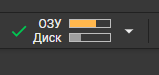


Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

In [1]:
import os
import time
import random
import gc

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import gdown

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    AveragePooling2D,
    Concatenate,
    Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K

plt.rcParams["axes.grid"] = True

print("Версия TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


Версия TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Скачиваем и распаковываем базу
DATA_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip"
ARCHIVE_NAME = "construction_256x192.zip"

gdown.download(DATA_URL, ARCHIVE_NAME, quiet=False)

!unzip -qo construction_256x192.zip

print("Данные распакованы. Папки train и val готовы к работе.")


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:02<00:00, 78.9MB/s]


Данные распакованы. Папки train и val готовы к работе.


In [3]:
# Основные параметры изображений и разметки
IMG_HEIGHT = 256
IMG_WIDTH = 192
NUM_CLASSES = 7

TRAIN_DIR = "train"
VAL_DIR = "val"

# Исходная база содержит 16 цветов масок
CLASS_COLORS = {
    "floor": (100, 100, 100),
    "ceiling": (0, 0, 100),
    "wall": (0, 100, 0),
    "column": (100, 0, 0),
    "aperture": (0, 100, 100),
    "door": (100, 0, 100),
    "window": (100, 100, 0),
    "external": (200, 200, 200),
    "railings": (0, 200, 0),
    "battery": (200, 0, 0),
    "people": (0, 200, 200),
    "ladder": (0, 0, 200),
    "inventory": (200, 0, 200),
    "lamp": (200, 200, 0),
    "wire": (0, 100, 200),
    "beam": (100, 0, 200),
}

LABEL_GROUPS = {
    0: ["floor"],
    1: ["ceiling"],
    2: ["wall"],
    3: ["aperture", "door", "window"],
    4: ["column", "railings", "ladder"],
    5: ["inventory"],
    6: ["lamp", "wire", "beam", "external", "battery", "people"],
}


def read_image_folder(root_dir, folder_name):
    folder_path = os.path.join(root_dir, folder_name)
    file_names = sorted(os.listdir(folder_path))

    loaded = []
    for name in file_names:
        file_path = os.path.join(folder_path, name)
        loaded.append(image.load_img(file_path, target_size=(IMG_HEIGHT, IMG_WIDTH)))

    return loaded


def images_to_float_array(pil_images):
    arrays = [image.img_to_array(img) for img in pil_images]
    return np.asarray(arrays, dtype="float32") / 255.0


def convert_masks_to_labels(mask_images):
    masks = []

    for mask in mask_images:
        rgb_mask = np.asarray(mask)
        label_mask = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype="uint8")

        for target_label, source_names in LABEL_GROUPS.items():
            for color_name in source_names:
                color = CLASS_COLORS[color_name]
                pixels = np.all(rgb_mask == color, axis=-1)
                label_mask[pixels] = target_label

        masks.append(label_mask)

    return np.asarray(masks)


print("Загрузка исходных изображений...")
train_img_raw = read_image_folder(TRAIN_DIR, "original")
val_img_raw = read_image_folder(VAL_DIR, "original")

x_train = images_to_float_array(train_img_raw)
x_val = images_to_float_array(val_img_raw)

del train_img_raw, val_img_raw
gc.collect()

print("Загрузка и преобразование цветных масок в 7 классов...")
train_mask_raw = read_image_folder(TRAIN_DIR, "segment")
val_mask_raw = read_image_folder(VAL_DIR, "segment")

y_train_sparse = convert_masks_to_labels(train_mask_raw)
y_val_sparse = convert_masks_to_labels(val_mask_raw)

del train_mask_raw, val_mask_raw
gc.collect()

print("Данные подготовлены")
print("x_train:", x_train.shape)
print("y_train_sparse:", y_train_sparse.shape)
print("x_val:", x_val.shape)
print("y_val_sparse:", y_val_sparse.shape)


Загрузка исходных изображений...
Загрузка и преобразование цветных масок в 7 классов...
Данные подготовлены
x_train: (1900, 256, 192, 3)
y_train_sparse: (1900, 256, 192, 1)
x_val: (100, 256, 192, 3)
y_val_sparse: (100, 256, 192, 1)


In [4]:
def conv_bn_block(x, filters, kernel_size=3):
    x = Conv2D(filters, kernel_size, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    return x


def pyramid_pooling_block(feature_map, feature_size=(32, 24), bins=(1, 2, 3, 6), filters=48):
    # PSPNet использует несколько масштабов усреднения
    feat_h, feat_w = feature_size
    branches = [feature_map]

    for bin_count in bins:
        stride_h = feat_h // bin_count
        stride_w = feat_w // bin_count

        pooled = AveragePooling2D(
            pool_size=(stride_h, stride_w),
            strides=(stride_h, stride_w),
            padding="same"
        )(feature_map)

        pooled = Conv2D(filters, 1, padding="same", activation="relu")(pooled)
        pooled = BatchNormalization()(pooled)

        resized = Lambda(lambda tensor: tf.image.resize(tensor, (feat_h, feat_w)))(pooled)
        branches.append(resized)

    return Concatenate(axis=-1)(branches)


def create_pspnet(input_shape=(256, 192, 3), class_count=7):
    inputs = Input(shape=input_shape)

    # Энкодер постепенно уменьшает размер карты признаков
    x = conv_bn_block(inputs, 48)
    x = conv_bn_block(x, 48)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = conv_bn_block(x, 96)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = conv_bn_block(x, 192)
    encoded = MaxPooling2D(pool_size=(2, 2))(x)

    # Пирамидальный блок собирает признаки разного масштаба
    x = pyramid_pooling_block(encoded, feature_size=(32, 24), bins=(1, 2, 3, 6), filters=48)

    # Декодер возвращает карту классов к размеру исходного изображения
    x = conv_bn_block(x, 192)
    x = Lambda(lambda tensor: tf.image.resize(tensor, (input_shape[0], input_shape[1])))(x)

    outputs = Conv2D(class_count, 1, padding="same", activation="softmax")(x)

    return Model(inputs=inputs, outputs=outputs, name="PSPNet_custom")


model = create_pspnet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), class_count=NUM_CLASSES)
model.summary()


Model: "PSPNet_custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 192,  │      1,344 │ input_layer[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 192,  │        192 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 192,  │     20,784 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 192,  │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 96,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 96,   │     41,568 │ max_pooling2d[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 96,   │        384 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 48,    │    166,080 │ max_pooling2d_1[… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 48,    │        768 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 1, 1, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 2, 2, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 4, 3, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 7, 6, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 1, 1, 48)  │      9,264 │ average_pooling2

 Total params: 934,999 (3.57 MB)

 Trainable params: 933,463 (3.56 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [5]:
K.clear_session()
gc.collect()

model.compile(
    optimizer=Adam(learning_rate=2e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Начало обучения модели PSPNet...")
start = time.time()

history = model.fit(
    x_train,
    y_train_sparse,
    epochs=15,
    batch_size=8,
    validation_data=(x_val, y_val_sparse),
    verbose=1
)

elapsed = round((time.time() - start) / 60, 2)
print(f"Обучение завершено Время: {elapsed} мин.")


Начало обучения модели PSPNet...
Epoch 1/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 71s 198ms/step - accuracy: 0.5869 - loss: 1.3038 - val_accuracy: 0.4566 - val_loss: 2.6411
Epoch 2/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.6896 - loss: 0.9647 - val_accuracy: 0.4740 - val_loss: 1.6813
Epoch 3/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.7155 - loss: 0.8464 - val_accuracy: 0.6089 - val_loss: 1.1408
Epoch 4/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.7354 - loss: 0.7783 - val_accuracy: 0.6127 - val_loss: 1.1450
Epoch 5/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.7484 - loss: 0.7304 - val_accuracy: 0.6204 - val_loss: 1.1185
Epoch 6/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 28s 116ms/step - accuracy: 0.7555 - loss: 0.7058 - val_accuracy: 0.6243 - val_loss: 1.1756
Epoch 7/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 28s 116ms/step - accuracy: 0.7675 - loss: 0.6718 - val_accuracy: 0.6326 - val_loss: 1.0558
Epoch 8/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 28s 116ms/

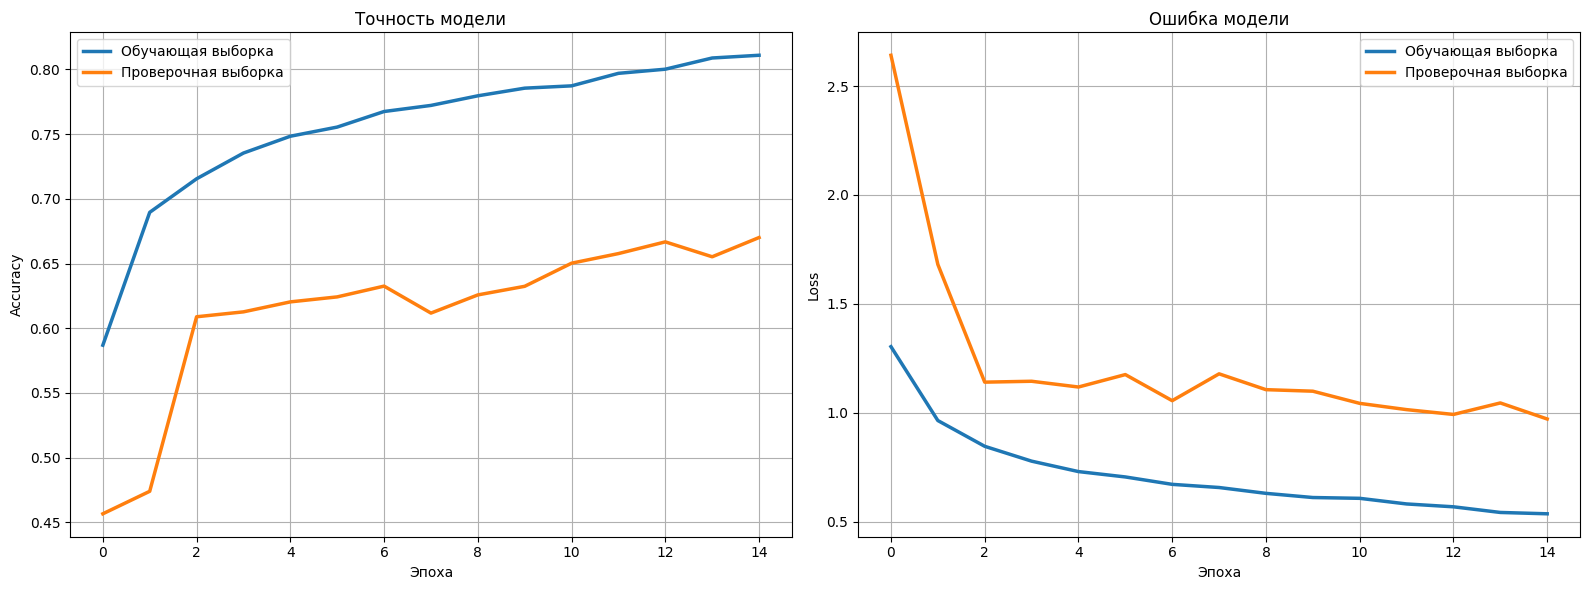

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


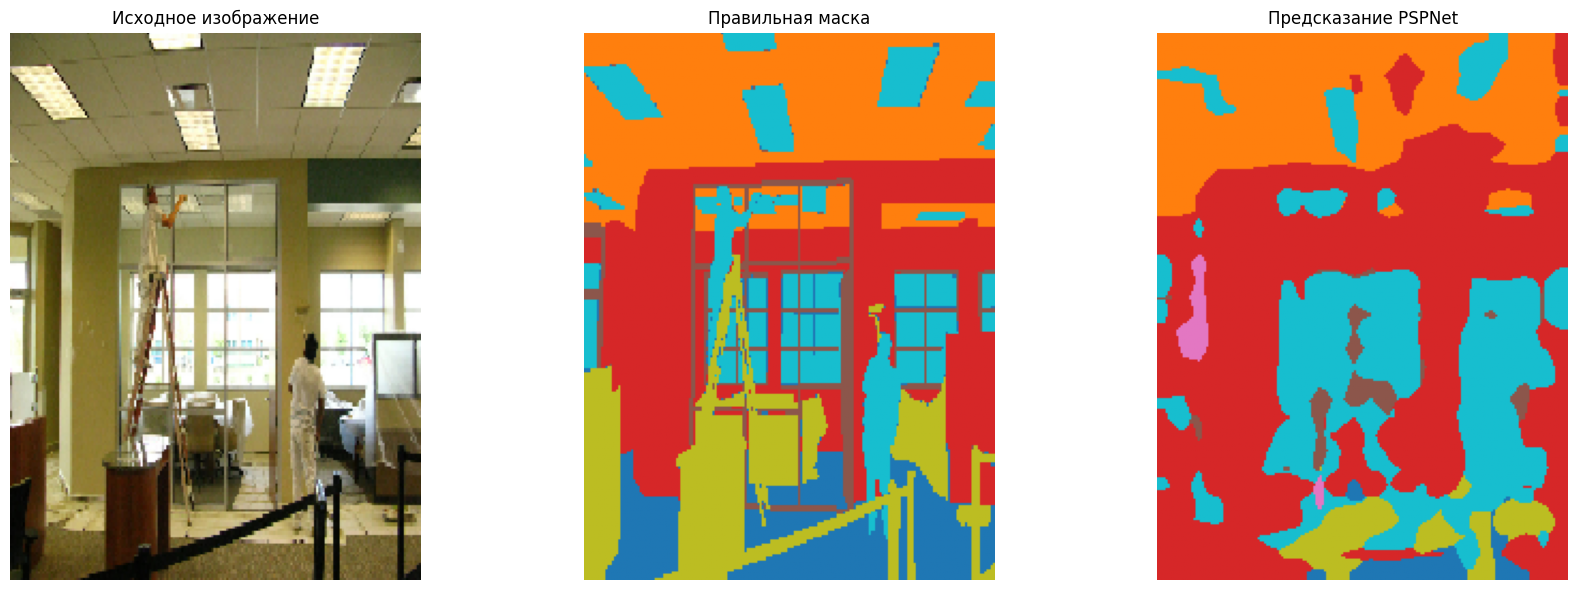

In [6]:
def show_training_history(train_history):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(train_history.history["accuracy"], label="Обучающая выборка", linewidth=2.5)
    axes[0].plot(train_history.history["val_accuracy"], label="Проверочная выборка", linewidth=2.5)
    axes[0].set_title("Точность модели")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(train_history.history["loss"], label="Обучающая выборка", linewidth=2.5)
    axes[1].plot(train_history.history["val_loss"], label="Проверочная выборка", linewidth=2.5)
    axes[1].set_title("Ошибка модели")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def show_segmentation_example(net, images, masks):
    idx = random.randint(0, len(images) - 1)

    probabilities = net.predict(np.expand_dims(images[idx], axis=0))
    predicted = np.argmax(probabilities[0], axis=-1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(images[idx])
    axes[0].set_title("Исходное изображение")
    axes[0].axis("off")

    axes[1].imshow(masks[idx].squeeze(), cmap="tab10")
    axes[1].set_title("Правильная маска")
    axes[1].axis("off")

    axes[2].imshow(predicted, cmap="tab10")
    axes[2].set_title("Предсказание PSPNet")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


show_training_history(history)
show_segmentation_example(model, x_val, y_val_sparse)
